Marseille Airbnb Price Analysis
Exploratory Data Analysis & Machine Learning

This project explores Airbnb listings in Marseille, France, to identify the main factors associated with nightly prices and evaluate the performance of machine learning models for price estimation.

The analysis covers data cleaning, exploratory data analysis, feature engineering, geographic patterns, hyperparameter tuning, amenities integration, and model error analysis.

1. Data Loading & Initial Exploration

In [1]:
import pandas as pd

In [2]:
marseille = pd.read_csv(
    "../data/Airbnb_Marseille_France_AirbnbMasterTable_07052026.csv"
)

marseille.shape

(6002, 68)

In [3]:
marseille.head()

,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,MapMarkerType,City,ListingTitle,Bathrooms,...,OutlierPrice_PerBedroom,OutlierPrice_PerGuest,AvailableOverThanTwoWeeks,AvailableOver30Days,AvailableOver90Days,AvailableOver180Days,AvailableMoreThan30Days,AvailableMoreThan90Days,AvailableMoreThan180Days,RecordInserted
0,France,Marseille,1.092830e+18,2026-05-06 20:52:24,43.298900,5.387800,EXACT,Marseille,Chic and quiet in the heart of the city,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,2026-05-06 20:52:24.000000
1,France,Marseille,1.094990e+18,2026-05-06 12:21:49,43.236674,5.403806,APPROX,Marseille,Renovated house with pool,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2026-05-06 12:21:49.000000
2,France,Marseille,1.099327e+18,2026-05-07 04:56:34,43.300200,5.368700,EXACT,Marseille,Charming T2 in the heart of Le Panier,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,2026-05-07 04:56:34.000000
3,France,Marseille,1.132605e+18,2026-05-06 10:36:23,43.294290,5.437980,APPROX,Marseille,rooms wanted Marseille,NaN,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2026-05-06 10:36:23.000000
4,France,Marseille,1.133975e+18,2026-05-06 18:36:10,43.282000,5.373740,APPROX,Marseille,House and garden in the heart of Marseille.,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,2026-05-06 18:36:10.000000


In [4]:
marseille.columns.tolist()

['Country',
 'Location',
 'Airbnb_ListingID',
 'Scrape_Date',
 'Lat',
 'Lng',
 'MapMarkerType',
 'City',
 'ListingTitle',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'PersonCapacity',
 'is_NewListing',
 'PictureCount',
 'is_GuestFavourite',
 'Host_ID',
 'Host_FirstName',
 'Host_isSuperhost',
 'Host_MultipleListings',
 'Host_MultipleListingsGlobal',
 'RoomType',
 'RoomType_Clean',
 'SpaceType',
 'SpaceType_Clean',
 'RoomAndPropertyType',
 'IsHomeOrServicedApartment',
 'ReviewCount',
 'StarRating',
 'RatingPct_5star',
 'RatingPct_4star',
 'RatingPct_3star',
 'RatingPct_2star',
 'RatingPct_1star',
 'LocationRating',
 'CleanlinessRating',
 'ValueRating',
 'AccuracyRating',
 'CheckinRating',
 'CommunicationRating',
 'VisibleReviewCount',
 'IsLowReviewScore',
 'NoReviewsNotNew',
 'Road',
 'Neighbourhood',
 'Suburb',
 'AddressCity',
 'StateDistrict',
 'Postcode',
 'IndexInSearchEngines',
 'BasicNightPrice_CheckIn',
 'BasicNightPrice_CheckOut',
 'Currency',
 'PrimaryPriceString',
 'BasicNightPrice',


In [5]:
for col in marseille.columns:
    print(col)

Country
Location
Airbnb_ListingID
Scrape_Date
Lat
Lng
MapMarkerType
City
ListingTitle
Bathrooms
Bedrooms
Beds
PersonCapacity
is_NewListing
PictureCount
is_GuestFavourite
Host_ID
Host_FirstName
Host_isSuperhost
Host_MultipleListings
Host_MultipleListingsGlobal
RoomType
RoomType_Clean
SpaceType
SpaceType_Clean
RoomAndPropertyType
IsHomeOrServicedApartment
ReviewCount
StarRating
RatingPct_5star
RatingPct_4star
RatingPct_3star
RatingPct_2star
RatingPct_1star
LocationRating
CleanlinessRating
ValueRating
AccuracyRating
CheckinRating
CommunicationRating
VisibleReviewCount
IsLowReviewScore
NoReviewsNotNew
Road
Neighbourhood
Suburb
AddressCity
StateDistrict
Postcode
IndexInSearchEngines
BasicNightPrice_CheckIn
BasicNightPrice_CheckOut
Currency
PrimaryPriceString
BasicNightPrice
BasicNightPrice_USD
Taxes
Taxes_USD
OutlierPrice_PerBedroom
OutlierPrice_PerGuest
AvailableOverThanTwoWeeks
AvailableOver30Days
AvailableOver90Days
AvailableOver180Days
AvailableMoreThan30Days
AvailableMoreThan90Days
Ava

In [6]:
[col for col in marseille.columns if "price" in col.lower()]

['BasicNightPrice_CheckIn',
 'BasicNightPrice_CheckOut',
 'PrimaryPriceString',
 'BasicNightPrice',
 'BasicNightPrice_USD',
 'OutlierPrice_PerBedroom',
 'OutlierPrice_PerGuest']

In [7]:
marseille[
    [
        "BasicNightPrice_CheckIn",
        "BasicNightPrice_CheckOut",
        "PrimaryPriceString",
        "BasicNightPrice",
        "BasicNightPrice_USD",
        "OutlierPrice_PerBedroom",
        "OutlierPrice_PerGuest"
    ]
].head(10)

,BasicNightPrice_CheckIn,BasicNightPrice_CheckOut,PrimaryPriceString,BasicNightPrice,BasicNightPrice_USD,OutlierPrice_PerBedroom,OutlierPrice_PerGuest
0,2026-07-03,2026-07-08,5 nights x € 120.77,120.0,140.77,0.0,0.0
1,2026-07-23,2026-07-30,7 nights x € 195.46,195.0,228.75,0.0,0.0
2,2026-06-23,2026-06-28,5 nights x € 110.39,110.0,129.04,0.0,0.0
3,2026-05-07,2026-05-12,5 nights x € 93.55,93.0,109.10,0.0,0.0
4,2026-05-31,2026-06-05,5 nights x € 171.44,171.0,200.60,0.0,0.0
5,2026-09-01,2026-09-06,5 nights x € 53.79,53.0,62.17,0.0,0.0
6,2026-05-08,2026-05-15,7 nights x € 720.02,720.0,844.63,0.0,0.0
7,2026-08-18,2026-08-23,5 nights x € 145.01,145.0,170.10,0.0,0.0
8,2027-01-18,2027-01-23,5 nights x € 94.96,94.0,110.27,0.0,0.0
9,2026-05-24,2026-05-29,5 nights x € 123.00,123.0,144.29,0.0,0.0


In [8]:
marseille["BasicNightPrice"].describe()

count     5995.00000
mean       179.27990
std        276.84786
min         25.00000
25%         93.00000
50%        124.00000
75%        187.00000
max      11752.00000
Name: BasicNightPrice, dtype: float64

In [9]:
marseille.nlargest(
    10,
    "BasicNightPrice"
)[["BasicNightPrice", "PrimaryPriceString"]]

,BasicNightPrice,PrimaryPriceString
5503,11752.0,"5 nights x € 11,752.59"
4381,10524.0,"5 nights x € 10,524.71"
2601,4480.0,"5 nights x € 4,480.95"
5930,3536.0,"5 nights x € 3,536.30"
1824,3524.0,"5 nights x € 3,524.61"
2232,3518.0,"5 nights x € 3,518.76"
425,2748.0,"5 nights x € 2,748.12"
3348,2650.0,"5 nights x € 2,650.00"
5492,2500.0,"5 nights x € 2,500.00"
4116,2287.0,"7 nights x € 2,287.77"


Price outliers

Initial exploration revealed several unusually expensive listings, including an extreme nightly price above €11,000. These observations were inspected before applying any filtering rather than being removed automatically.

In [10]:
marseille.nlargest(
    10,
    "BasicNightPrice"
)[
    [
        "BasicNightPrice_CheckIn",
        "BasicNightPrice_CheckOut",
        "PrimaryPriceString",
        "BasicNightPrice"
    ]
]

,BasicNightPrice_CheckIn,BasicNightPrice_CheckOut,PrimaryPriceString,BasicNightPrice
5503,2026-05-07,2026-05-12,"5 nights x € 11,752.59",11752.0
4381,2026-05-06,2026-05-11,"5 nights x € 10,524.71",10524.0
2601,2026-06-04,2026-06-09,"5 nights x € 4,480.95",4480.0
5930,2026-11-17,2026-11-22,"5 nights x € 3,536.30",3536.0
1824,2026-08-29,2026-09-03,"5 nights x € 3,524.61",3524.0
2232,2026-09-12,2026-09-17,"5 nights x € 3,518.76",3518.0
425,2026-05-26,2026-05-31,"5 nights x € 2,748.12",2748.0
3348,2026-05-06,2026-05-11,"5 nights x € 2,650.00",2650.0
5492,2026-05-07,2026-05-12,"5 nights x € 2,500.00",2500.0
4116,2026-05-14,2026-05-21,"7 nights x € 2,287.77",2287.0


In [11]:
marseille.loc[5503]


Country                                         France
Location                                     Marseille
Airbnb_ListingID                 1091225851621574912.0
Scrape_Date                        2026-05-06 11:30:17
Lat                                          43.307004
                                       ...            
AvailableOver180Days                               0.0
AvailableMoreThan30Days                            1.0
AvailableMoreThan90Days                            0.0
AvailableMoreThan180Days                           0.0
RecordInserted              2026-05-06 11:30:17.000000
Name: 5503, Length: 68, dtype: object

## 3. Feature Exploration

Candidate features were selected based on whether they describe characteristics that would be available when estimating the nightly price of a property. Variables directly derived from price, post-stay ratings, and identifiers were excluded.

In [12]:
[col for col in marseille.columns if any(
    word in col.lower()
    for word in ["name", "bed", "bath", "guest", "room", "property", "location"]
)]

['Location',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'is_GuestFavourite',
 'Host_FirstName',
 'RoomType',
 'RoomType_Clean',
 'RoomAndPropertyType',
 'LocationRating',
 'OutlierPrice_PerBedroom',
 'OutlierPrice_PerGuest']

In [13]:
[col for col in marseille.columns if any(
    word in col.lower()
    for word in ["accommod", "capacity", "person", "people"]
)]

['PersonCapacity']

In [16]:
marseille.info()

<class 'pandas.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 68 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      6001 non-null   str    
 1   Location                     6000 non-null   str    
 2   Airbnb_ListingID             6000 non-null   float64
 3   Scrape_Date                  6000 non-null   str    
 4   Lat                          6000 non-null   float64
 5   Lng                          6000 non-null   float64
 6   MapMarkerType                6000 non-null   str    
 7   City                         6000 non-null   str    
 8   ListingTitle                 6000 non-null   str    
 9   Bathrooms                    5902 non-null   float64
 10  Bedrooms                     5511 non-null   float64
 11  Beds                         5989 non-null   float64
 12  PersonCapacity               6000 non-null   float64
 13  is_NewListing                

In [17]:
missing = marseille.isnull().sum().sort_values(ascending=False)

missing.head(15)

Neighbourhood          5455
RatingPct_4star        1133
RatingPct_1star        1133
RatingPct_3star        1133
RatingPct_2star        1133
RatingPct_5star        1133
ValueRating             652
CommunicationRating     652
AccuracyRating          652
CheckinRating           652
CleanlinessRating       652
LocationRating          652
StarRating              652
Bedrooms                491
AddressCity             188
dtype: int64

In [18]:
missing_pct = (
    marseille.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct.head(15)

Neighbourhood          90.886371
RatingPct_4star        18.877041
RatingPct_1star        18.877041
RatingPct_3star        18.877041
RatingPct_2star        18.877041
RatingPct_5star        18.877041
ValueRating            10.863046
CommunicationRating    10.863046
AccuracyRating         10.863046
CheckinRating          10.863046
CleanlinessRating      10.863046
LocationRating         10.863046
StarRating             10.863046
Bedrooms                8.180606
AddressCity             3.132289
dtype: float64

In [19]:
[col for col in marseille.columns if any(
    word in col.lower()
    for word in ["lat", "lon", "geo", "postal", "zipcode", "district"]
)]

['Lat', 'StateDistrict']

In [20]:
marseille["StateDistrict"].value_counts(dropna=False).head(30)

StateDistrict
Provence-Alpes-Côte d'Azur    6000
NaN                              2
Name: count, dtype: int64

In [21]:
[col for col in marseille.columns if any(
    word in col.lower()
    for word in ["lat", "lng", "lon", "long", "coord", "geo"]
)]

['Lat', 'Lng']

In [22]:
marseille[["Lat", "Lng"]].describe()

,Lat,Lng
count,6000.000000,6000.000000
mean,43.290121,5.387938
std,0.028066,0.030036
min,43.207200,5.326940
25%,43.280600,5.369700
50%,43.292435,5.381535
75%,43.301100,5.397400
max,43.393400,5.522470


In [23]:
marseille[["Lat", "Lng"]].isna().sum()

Lat    2
Lng    2
dtype: int64

In [24]:
features = [
    "Bedrooms",
    "Bathrooms",
    "Beds",
    "RoomType",
    "Lat",
    "Lng",
    "PersonCapacity",
    "Postcode",
    "AddressCity",
    "ValueRating",
    "IsHomeOrServicedApartment"
]

marseille[features].info()

<class 'pandas.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Bedrooms                   5511 non-null   float64
 1   Bathrooms                  5902 non-null   float64
 2   Beds                       5989 non-null   float64
 3   RoomType                   6000 non-null   str    
 4   Lat                        6000 non-null   float64
 5   Lng                        6000 non-null   float64
 6   PersonCapacity             6000 non-null   float64
 7   Postcode                   6000 non-null   float64
 8   AddressCity                5814 non-null   str    
 9   ValueRating                5350 non-null   float64
 10  IsHomeOrServicedApartment  6000 non-null   float64
dtypes: float64(9), str(2)
memory usage: 658.8 KB


In [25]:
marseille[features].isna().mean().sort_values(ascending=False) * 100

ValueRating                  10.863046
Bedrooms                      8.180606
AddressCity                   3.132289
Bathrooms                     1.666111
Beds                          0.216594
RoomType                      0.033322
Lat                           0.033322
PersonCapacity                0.033322
Lng                           0.033322
Postcode                      0.033322
IsHomeOrServicedApartment     0.033322
dtype: float64

In [26]:
marseille["AddressCity"].value_counts(dropna=False).head(20)

AddressCity
Marseille    5814
NaN           188
Name: count, dtype: int64

In [27]:
marseille["Postcode"].value_counts(dropna=False).head(30)

Postcode
13008.0    878
13001.0    849
13007.0    808
13006.0    570
13002.0    518
13009.0    432
13005.0    384
13004.0    290
13003.0    195
13012.0    193
13010.0    169
13013.0    164
13011.0    118
13015.0     92
13190.0     89
13014.0     83
13016.0     49
13380.0     32
13170.0     30
13302.0     19
13821.0     15
13260.0     10
13240.0      9
13400.0      2
NaN          2
13331.0      1
10003.0      1
Name: count, dtype: int64

In [28]:
marseille_postcodes = [
    13001, 13002, 13003, 13004,
    13005, 13006, 13007, 13008,
    13009, 13010, 13011, 13012,
    13013, 13014, 13015, 13016
]

marseille["is_marseille_postcode"] = (
    marseille["Postcode"].isin(marseille_postcodes)
)

In [29]:
marseille["is_marseille_postcode"].value_counts()

is_marseille_postcode
True     5792
False     210
Name: count, dtype: int64

In [30]:
df_clean = marseille[
    marseille["is_marseille_postcode"]
].copy()

df_clean.shape

(5792, 69)

In [31]:
import matplotlib.pyplot as plt

In [32]:
df_clean["BasicNightPrice"].quantile(0.99)

np.float64(923.5600000000013)

Extreme values strongly distorted the initial price distribution. After inspecting the upper tail, extreme outliers were handled to provide a more informative view of typical nightly prices.

In [33]:
df_clean["BasicNightPrice"].quantile(
    [0.90, 0.95, 0.975, 0.99, 0.995]
)

0.900     315.00
0.950     446.70
0.975     601.00
0.990     923.56
0.995    1100.68
Name: BasicNightPrice, dtype: float64

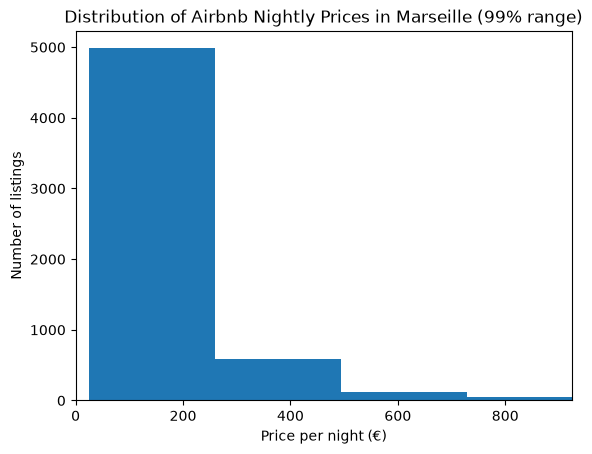

In [34]:
price_99 = df_clean["BasicNightPrice"].quantile(0.99)

plt.hist(
    df_clean["BasicNightPrice"].dropna(),
    bins=50
)

plt.xlim(0, price_99)

plt.xlabel("Price per night (€)")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Nightly Prices in Marseille (99% range)")

plt.show()

In [35]:
in_range = df_clean[
    df_clean["BasicNightPrice"].between(25, 225)
]

len(in_range) / len(df_clean) * 100

81.75069060773481

In [36]:
df_clean.groupby("Bedrooms")["BasicNightPrice"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
Bedrooms,,,
1.0,3064,105.0,117.026436
2.0,1332,156.5,182.214715
3.0,583,257.0,304.879931
4.0,243,406.0,475.518519
5.0,72,525.0,598.500000
6.0,18,580.0,1324.111111
7.0,2,895.0,895.000000
8.0,3,649.0,654.333333
9.0,2,1276.0,1276.000000


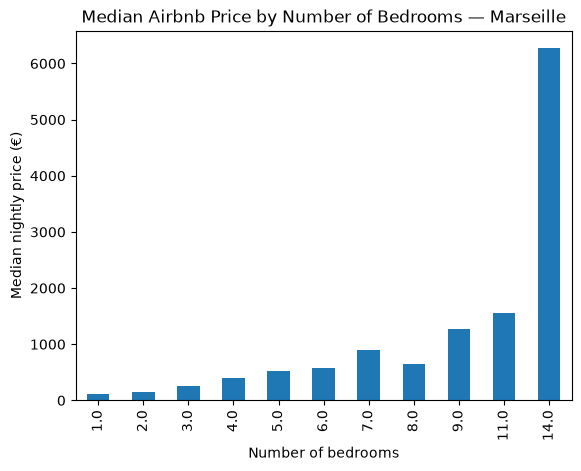

In [37]:
price_by_bedrooms = (
    df_clean
    .groupby("Bedrooms")["BasicNightPrice"]
    .median()
)

price_by_bedrooms.plot(kind="bar")

plt.xlabel("Number of bedrooms")
plt.ylabel("Median nightly price (€)")
plt.title("Median Airbnb Price by Number of Bedrooms — Marseille")
plt.show()

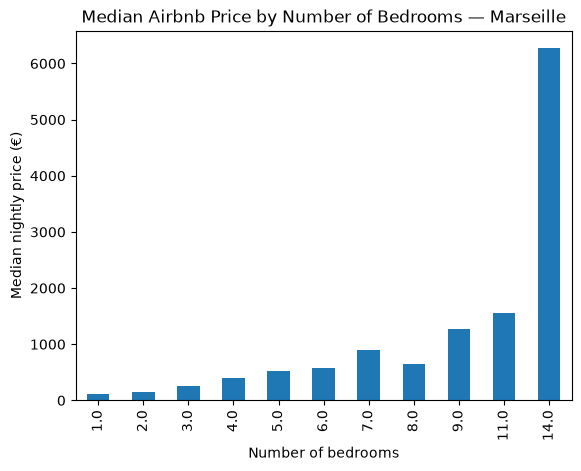

In [38]:
price_by_bedrooms = (
    df_clean
    .groupby("Bedrooms")["BasicNightPrice"]
    .median()
)

price_by_bedrooms.plot(kind="bar")

plt.xlabel("Number of bedrooms")
plt.ylabel("Median nightly price (€)")
plt.title("Median Airbnb Price by Number of Bedrooms — Marseille")
plt.show()

In [39]:
df_clean["Bedrooms"].value_counts().sort_index()

Bedrooms
1.0     3067
2.0     1333
3.0      584
4.0      243
5.0       72
6.0       18
7.0        2
8.0        3
9.0        2
11.0       1
14.0       2
Name: count, dtype: int64

In [40]:
price_by_postcode = (
    df_clean
    .groupby("Postcode")["BasicNightPrice"]
    .agg(["count", "median"])
    .sort_values("median", ascending=False)
)

price_by_postcode

,count,median
Postcode,,
13008.0,878,160.0
13007.0,808,152.0
13011.0,118,139.0
13012.0,193,137.0
13016.0,49,128.0
13006.0,570,127.0
13009.0,427,125.0
13002.0,518,120.0
13001.0,849,116.0


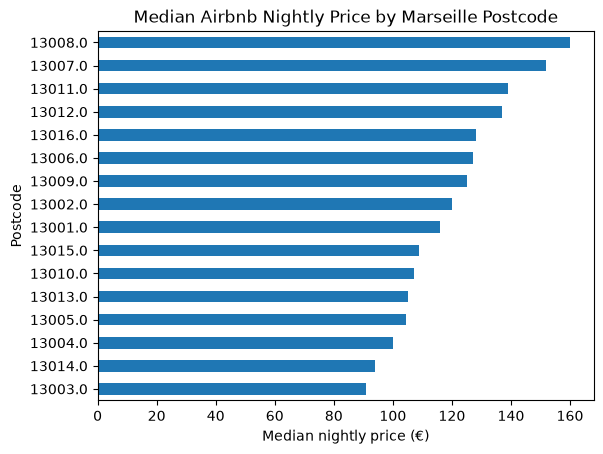

In [41]:
price_by_postcode_sorted = (
    df_clean
    .groupby("Postcode")["BasicNightPrice"]
    .median()
    .sort_values()
)

price_by_postcode_sorted.plot(kind="barh")

plt.xlabel("Median nightly price (€)")
plt.ylabel("Postcode")
plt.title("Median Airbnb Nightly Price by Marseille Postcode")
plt.show()

In [42]:
capacity_analysis = (
    df_clean
    .groupby("PersonCapacity")["BasicNightPrice"]
    .agg(["count", "median", "mean"])
)

capacity_analysis

,count,median,mean
PersonCapacity,,,
1.0,162,58.0,77.438272
2.0,2084,96.0,107.876200
3.0,377,109.0,128.875332
4.0,1782,134.0,160.289001
5.0,292,164.0,204.000000
6.0,668,220.0,269.549401
7.0,92,317.5,358.880435
8.0,210,375.0,444.323810
9.0,17,426.0,515.058824


In [43]:
df_clean["RoomType"].value_counts()

RoomType
Entire home/flat    4951
Private room         822
Shared room           19
Name: count, dtype: int64

In [44]:
df_clean.groupby("RoomType")["BasicNightPrice"].agg(
    ["count", "median", "mean"]
).sort_values("median")

,count,median,mean
RoomType,,,
Shared room,19,43.0,60.368421
Private room,822,72.0,94.531630
Entire home/flat,4946,134.0,192.913465


## 4. Model Preparation

The selected features were divided into numerical and categorical variables. `BasicNightPrice` was used as the prediction target.

In [45]:
numeric_features = [
    "Bedrooms",
    "Bathrooms",
    "Beds",
    "PersonCapacity",
    "Lat",
    "Lng"
]

categorical_features = [
    "RoomType",
    "Postcode",
    "IsHomeOrServicedApartment"
]

target = "BasicNightPrice"

In [46]:
X = df_clean[numeric_features + categorical_features]
y = df_clean[target]

In [47]:
X.shape, y.shape

((5792, 9), (5792,))

In [48]:
import sklearn

print(sklearn.__version__)

1.9.0


In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
X_train.shape, X_test.shape

((4633, 9), (1159, 9))

In [52]:
model_df = df_clean.dropna(subset=["BasicNightPrice"]).copy()

X = model_df[numeric_features + categorical_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((4629, 9), (1158, 9))

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [54]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [55]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Baseline Model — Linear Regression

In [57]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [58]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Bedrooms','Bathrooms','Beds',...,'RoomType','Postcode', 'IsHomeOrServicedApartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [60]:
y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(69.03797524805215, np.float64(150.33182419927078), 0.4014037818650703)

## 6. Data Cleaning & Feature Selection

In [61]:
price_limit = df_clean["BasicNightPrice"].quantile(0.995)

model_df_trimmed = df_clean[
    (df_clean["BasicNightPrice"].notna()) &
    (df_clean["BasicNightPrice"] <= price_limit)
].copy()

In [62]:
model_df.shape, model_df_trimmed.shape

((5787, 69), (5758, 69))

In [63]:
X_trimmed = model_df_trimmed[numeric_features + categorical_features]
y_trimmed = model_df_trimmed[target]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_trimmed,
    y_trimmed,
    test_size=0.2,
    random_state=42
)

In [64]:
linear_model_trimmed = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model_trimmed.fit(X_train_t, y_train_t)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Bedrooms','Bathrooms','Beds',...,'RoomType','Postcode', 'IsHomeOrServicedApartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [65]:
y_pred_t = linear_model_trimmed.predict(X_test_t)

mae_t = mean_absolute_error(y_test_t, y_pred_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
r2_t = r2_score(y_test_t, y_pred_t)

mae_t, rmse_t, r2_t

(51.67404559627375, np.float64(91.64107479782338), 0.558375051218271)

## 7. Random Forest Regression

A Random Forest regressor was evaluated to capture non-linear relationships and interactions between property characteristics.

In [66]:
from sklearn.ensemble import RandomForestRegressor

In [67]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [68]:
rf_model.fit(X_train_t, y_train_t)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Bedrooms','Bathrooms','Beds',...,'RoomType','Postcode', 'IsHomeOrServicedApartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [69]:
rf_train_pred = rf_model.predict(X_train_t)
rf_test_pred = rf_model.predict(X_test_t)

r2_train_rf = r2_score(y_train_t, rf_train_pred)
r2_test_rf = r2_score(y_test_t, rf_test_pred)

mae_rf = mean_absolute_error(y_test_t, rf_test_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test_t, rf_test_pred))

r2_train_rf, r2_test_rf, mae_rf, rmse_rf

(0.9381578807740818,
 0.5525874077071604,
 51.613666336087235,
 np.float64(92.2396137236))

### Controlling Overfitting

In [70]:
rf_model_10 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [71]:
rf_model_10.fit(X_train_t, y_train_t)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Bedrooms','Bathrooms','Beds',...,'RoomType','Postcode', 'IsHomeOrServicedApartment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subs

In [72]:
train_pred = rf_model_10.predict(X_train_t)
test_pred = rf_model_10.predict(X_test_t)

print("R² train:", r2_score(y_train_t, train_pred))
print("R² test:", r2_score(y_test_t, test_pred))
print("MAE:", mean_absolute_error(y_test_t, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_t, test_pred)))

R² train: 0.7276304482088434
R² test: 0.5690122466125405
MAE: 50.209407440426304
RMSE: 90.53069176952499


## 8. Cross-Validation & Hyperparameter Tuning

Cross-validation was used to evaluate whether the model's performance remained consistent across different subsets of the data and to select hyperparameters more systematically.

In [73]:
from sklearn.model_selection import cross_val_score

In [74]:
depths = [5, 10, 15, 20, 25]

In [75]:
for depth in depths:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=200,
                max_depth=depth,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ))
        ]
    )

    scores = cross_val_score(
        model,
        X_train_t,
        y_train_t,
        cv=5,
        scoring="r2"
    )

    print(
        f"Depth: {depth} | "
        f"R² medio: {scores.mean():.3f} | "
        f"Desv: {scores.std():.3f}"
    )

Depth: 5 | R² medio: 0.577 | Desv: 0.039
Depth: 10 | R² medio: 0.588 | Desv: 0.040
Depth: 15 | R² medio: 0.587 | Desv: 0.040
Depth: 20 | R² medio: 0.586 | Desv: 0.040
Depth: 25 | R² medio: 0.586 | Desv: 0.040


In [76]:
param_grid = {
    "model__max_depth": [5, 10, 15],
    "model__min_samples_leaf": [2, 5, 10],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

### Grid Search

In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [79]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [80]:
grid_search.fit(X_train_t, y_train_t)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 0.7, ...], 'model__min_samples_leaf': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [81]:
grid_search.best_params_

{'model__max_depth': 10,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 2}

In [82]:
grid_search.best_score_

np.float64(0.5940273034827059)

In [83]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test_t)

mae_best = mean_absolute_error(y_test_t, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_t, y_pred_best))
r2_best = r2_score(y_test_t, y_pred_best)

print("MAE:", mae_best)
print("RMSE:", rmse_best)
print("R²:", r2_best)

MAE: 49.300242590993456
RMSE: 88.83883308071854
R²: 0.5849705234835716


RoomAndPropertyType combines information about room access (Entire, Private room, Shared room) with the underlying property type. Since RoomType already captures the first component, a separate PropertyType feature was engineered to reduce redundancy and preserve property information.

In [84]:
df_clean["RoomAndPropertyType"].value_counts().head(30)

RoomAndPropertyType
Entire rental unit                   3601
Entire home                           575
Private room in rental unit           408
Entire apartment                      273
Entire villa                          170
Entire townhouse                      151
Private room in bed and breakfast     136
Private room in home                   82
Private room in apartment              61
Entire loft                            57
Private room in townhouse              36
Entire guest house                     31
Private room in guest suite            21
Entire guest suite                     17
Private room in villa                  17
Room in aparthotel                     16
Entire place                           15
Private room in guest house            14
Room in hotel                          14
Entire serviced apartment              11
Entire holiday home                     9
Tiny home                               9
Shared room in hostel                   8
Private room i

In [85]:
def extract_property_type(value):
    if pd.isna(value):
        return "Unknown"

    value = value.lower()

    if value.startswith("entire "):
        return value.replace("entire ", "", 1)

    if value.startswith("private room in "):
        return value.replace("private room in ", "", 1)

    if value.startswith("shared room in "):
        return value.replace("shared room in ", "", 1)

    return value

In [86]:
df_clean["PropertyType"] = (
    df_clean["RoomAndPropertyType"]
    .apply(extract_property_type)
)

In [87]:
df_clean["PropertyType"].value_counts()

PropertyType
rental unit               4011
home                       658
apartment                  336
townhouse                  188
villa                      187
bed and breakfast          140
loft                        60
guest house                 45
guest suite                 38
room in aparthotel          16
hostel                      15
place                       15
room in hotel               14
serviced apartment          12
holiday home                10
tiny home                   10
cabin                        7
casa particular              6
room in boutique hotel       6
nature lodge                 4
boat                         3
chalet                       3
castle                       2
camper van/motorhome         2
cottage                      1
bungalow                     1
private room                 1
cave                         1
Name: count, dtype: int64

In [88]:
categorical_features_v2 = [
    "RoomType",
    "Postcode",
    "IsHomeOrServicedApartment",
    "PropertyType"
]

In [89]:
numeric_features_v2 = [
    "Bedrooms",
    "Bathrooms",
    "Beds",
    "PersonCapacity",
    "Lat",
    "Lng"
]

In [90]:
price_limit = df_clean["BasicNightPrice"].quantile(0.995)

model_df_trimmed_v2 = df_clean[
    (df_clean["BasicNightPrice"].notna()) &
    (df_clean["BasicNightPrice"] <= price_limit)
].copy()

X_v2 = model_df_trimmed_v2[
    numeric_features_v2 + categorical_features_v2
]

y_v2 = model_df_trimmed_v2[target]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42
)

X_train_v2.shape, X_test_v2.shape

((4606, 10), (1152, 10))

In [91]:
preprocessor_v2 = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features_v2), ("cat", categorical_transformer, categorical_features_v2)])

In [92]:
rf_v2 = Pipeline(steps=[("preprocessor", preprocessor_v2), ("model", RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, max_features="sqrt", random_state=42, n_jobs=-1))])

In [93]:
rf_v2.fit(X_train_v2, y_train_v2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Bedrooms','Bathrooms','Beds',...,'Postcode','IsHomeOrServicedApartment', 'PropertyType']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [94]:
y_pred_v2 = rf_v2.predict(X_test_v2)

print("MAE:", mean_absolute_error(y_test_v2, y_pred_v2))
print("RMSE:", np.sqrt(mean_squared_error(y_test_v2, y_pred_v2)))
print("R²:", r2_score(y_test_v2, y_pred_v2))

MAE: 49.23193741139047
RMSE: 88.05721191666584
R²: 0.592241415342188


Geographic Clustering with K-Means

Geographic clusters were created using only latitude and longitude, without using price information. Median nightly prices differed across clusters, suggesting spatial structure in the Marseille Airbnb market.

In [96]:
from sklearn.cluster import KMeans

In [97]:
geo_train = X_train_v2[["Lat", "Lng"]].dropna()

kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

kmeans.fit(geo_train)

,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 2)","[[43.

In [98]:
geo_train = geo_train.copy()
geo_train["GeoCluster"] = kmeans.predict(
    geo_train[["Lat", "Lng"]]
)

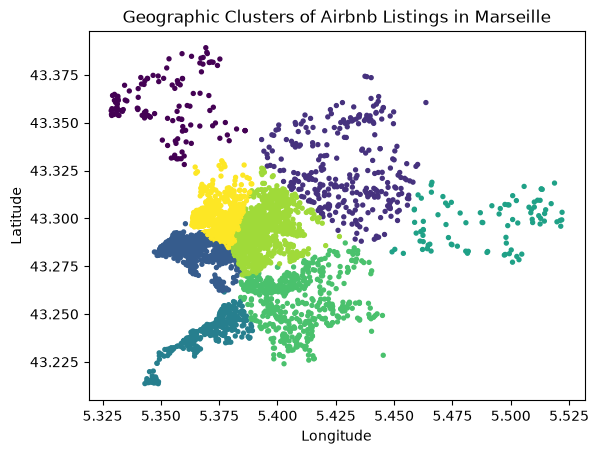

In [99]:
plt.scatter(
    geo_train["Lng"],
    geo_train["Lat"],
    c=geo_train["GeoCluster"],
    s=8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Clusters of Airbnb Listings in Marseille")
plt.show()

In [100]:
geo_train["Price"] = y_train_v2.loc[geo_train.index]

In [101]:
cluster_prices = (
    geo_train
    .groupby("GeoCluster")["Price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

cluster_prices

,count,median,mean
GeoCluster,,,
3,378,169.5,235.735450
4,92,152.5,237.369565
2,767,152.0,207.865711
5,514,128.0,174.503891
7,1259,118.0,141.691819
1,285,118.0,175.333333
0,126,116.5,161.722222
6,1185,110.0,134.392405


Modeling result: Adding the geographic cluster as an additional categorical feature produced only a marginal improvement in test R² (0.592 → 0.593). Since latitude, longitude and postcode already captured geographic information, GeoCluster was not retained in the final feature set.

## 10. Amenities Data Integration

Amenities data was available for 3,918 of the 5,758 listings in the modeling dataset (≈68%). Missing amenity records were not interpreted as the absence of amenities.

In [149]:
amenities = pd.read_csv(
    "../data/Airbnb_Marseille_France_Amenities_07052026.csv"
)

amenities.shape

(181508, 9)

In [103]:
amenities.columns.tolist()

['Country',
 'Location',
 'Airbnb_ListingID',
 'Scrape_Date',
 'Amenity_Group',
 'Amenity_Key',
 'Amenity_Title',
 'Amenity_Subtitle',
 'RecordInserted']

In [104]:
amenities["Amenity_Title"].value_counts().head(30)

Amenity_Title
Kitchen                 5603
Wifi                    5242
Hot water               4761
Smoke alarm             4414
Crockery and cutlery    4313
Bed linen               4311
Cooking basics          4142
Hairdryer               3985
Hangers                 3904
Fridge                  3857
Washing machine         3712
Microwave               3705
TV                      3548
Essentials              3469
Iron                    3448
Heating                 3443
Kettle                  3038
Dining table            2936
Freezer                 2911
Wine glasses            2849
Baking sheet            2782
Cleaning products       2768
Oven                    2625
Dedicated workspace     2623
Toaster                 2583
Air conditioning        2573
Clothes drying rack     2567
Dishwasher              2529
Shower gel              2432
Shampoo                 2221
Name: count, dtype: int64

In [105]:
amenities["Amenity_Group"].value_counts()

Amenity_Group
Kitchen and dining         56021
Bedroom and laundry        30798
Bathroom                   20133
Services                   10493
Heating and cooling        10385
Internet and office         8575
Outdoor                     8457
Entertainment               8410
Parking and facilities      8266
Home safety                 7784
Family                      5177
Location features           4368
Scenic views                1854
Privacy and safety           758
Popular                       25
Included with your stay        2
Name: count, dtype: int64

In [106]:
keywords = [
    "pool",
    "parking",
    "balcony",
    "terrace",
    "sea",
    "view",
    "beach",
    "air conditioning",
    "hot tub",
    "jacuzzi",
    "garden",
    "patio",
    "elevator"
]

premium_amenities = amenities[
    amenities["Amenity_Title"]
    .str.lower()
    .str.contains("|".join(keywords), na=False)
]

premium_amenities["Amenity_Title"].value_counts()

Amenity_Title
Air conditioning                                                                  2573
Free parking on premises                                                          1824
Free on-street parking                                                            1588
Private patio or balcony                                                          1153
Central air conditioning                                                           674
                                                                                  ... 
Shared outdoor pool – olympic-sized, lap pool, saltwater                             1
Shared outdoor pool – available seasonally, open specific hours, olympic-sized       1
Whirpool 6th sense tactile stainless steel oven                                      1
WHIRPOOL stainless steel oven                                                        1
Private outdoor pool – open specific hours                                           1
Name: count, Length: 198, dty

In [107]:
amenity_count = (
    amenities
    .groupby("Airbnb_ListingID")
    .size()
    .describe()
)

amenity_count

count    6000.000000
mean       30.251000
std        14.836993
min         1.000000
25%        19.000000
50%        31.000000
75%        41.000000
max       108.000000
dtype: float64

In [108]:
amenities[
    amenities["Amenity_Title"]
    .str.contains(
        "pool|parking|air conditioning|sea view|beach|patio|balcony",
        case=False,
        na=False
    )
][
    ["Amenity_Key", "Amenity_Title"]
].head(50)

,Amenity_Key,Amenity_Title
32,PATIO_BALCONY,Private patio or balcony
33,CAR_RENTAL,Free parking on premises
44,SNOWFLAKE,Air conditioning
63,CAR_RENTAL,Free parking on premises
64,POOL,Private pool
74,CAR_RENTAL,Free parking on premises
91,SNOWFLAKE,Air conditioning
104,PATIO_BALCONY,Private patio or balcony
107,CAR_RENTAL,Free parking on premises
150,CAR_RENTAL,Free parking on premises


In [109]:
amenity_features = (
    amenities.groupby("Airbnb_ListingID")
    .size()
    .rename("AmenityCount")
    .to_frame()
)

amenity_features.head()

,AmenityCount
Airbnb_ListingID,
151612.0,21
188282.0,41
203436.0,47
224931.0,19
272214.0,38


In [110]:
premium_keys = {
    "HasAirConditioning": "SNOWFLAKE",
    "HasParking": "CAR_RENTAL",
    "HasOutdoorSpace": "PATIO_BALCONY",
    "HasBeachAccess": "BEACH",
    "HasSeaView": "VIEW_OCEAN"
}

for feature, key in premium_keys.items():
    ids = amenities.loc[
        amenities["Amenity_Key"] == key,
        "Airbnb_ListingID"
    ].unique()

    amenity_features[feature] = (
        amenity_features.index.isin(ids).astype(int)
    )

In [111]:
pool_mask = (
    amenities["Amenity_Title"].str.contains(
        "pool",
        case=False,
        na=False
    )
    &
    ~amenities["Amenity_Title"].str.contains(
        "pool view",
        case=False,
        na=False
    )
)

pool_ids = amenities.loc[
    pool_mask,
    "Airbnb_ListingID"
].unique()

amenity_features["HasPool"] = (
    amenity_features.index.isin(pool_ids).astype(int)
)

In [112]:
amenity_features[
    [
        "HasAirConditioning",
        "HasParking",
        "HasOutdoorSpace",
        "HasBeachAccess",
        "HasSeaView",
        "HasPool"
    ]
].sum()

HasAirConditioning    3458
HasParking            4176
HasOutdoorSpace       1749
HasBeachAccess        1252
HasSeaView             671
HasPool                701
dtype: int64

In [113]:
amenity_features["AmenityCount"].describe()

count    6000.000000
mean       30.251000
std        14.836993
min         1.000000
25%        19.000000
50%        31.000000
75%        41.000000
max       108.000000
Name: AmenityCount, dtype: float64

In [114]:
model_enriched = model_df_trimmed_v2.merge(
    amenity_features,
    left_on="Airbnb_ListingID",
    right_index=True,
    how="left"
)

In [115]:
print("Antes:", model_df_trimmed_v2.shape)
print("Después:", model_enriched.shape)

Antes: (5758, 70)
Después: (5758, 77)


In [116]:
model_enriched["AmenityCount"].isna().sum()

np.int64(1840)

In [117]:
print("Master ID dtype:", model_df_trimmed_v2["Airbnb_ListingID"].dtype)
print("Amenities ID dtype:", amenities["Airbnb_ListingID"].dtype)

print("Listings únicos Master:", model_df_trimmed_v2["Airbnb_ListingID"].nunique())
print("Listings únicos Amenities:", amenities["Airbnb_ListingID"].nunique())

Master ID dtype: float64
Amenities ID dtype: float64
Listings únicos Master: 5758
Listings únicos Amenities: 6000


In [118]:
master_ids = set(model_df_trimmed_v2["Airbnb_ListingID"].dropna())
amenity_ids = set(amenities["Airbnb_ListingID"].dropna())

print("Coinciden:", len(master_ids & amenity_ids))
print("Solo Master:", len(master_ids - amenity_ids))
print("Solo Amenities:", len(amenity_ids - master_ids))

Coinciden: 3918
Solo Master: 1840
Solo Amenities: 2082


In [119]:
model_amenities = model_enriched[
    model_enriched["AmenityCount"].notna()
].copy()

model_amenities.shape

(3918, 77)

In [120]:
base_features = numeric_features_v2 + categorical_features_v2

X_base = model_amenities[base_features]
y_base = model_amenities[target]

In [121]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42
)

In [122]:
rf_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_base.fit(X_train_base, y_train_base)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Bedrooms','Bathrooms','Beds',...,'Postcode','IsHomeOrServicedApartment', 'PropertyType']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [123]:
pred_base = rf_base.predict(X_test_base)

print("MAE:", mean_absolute_error(y_test_base, pred_base))
print("RMSE:", np.sqrt(mean_squared_error(y_test_base, pred_base)))
print("R²:", r2_score(y_test_base, pred_base))

MAE: 48.92561051446826
RMSE: 86.97761856263135
R²: 0.6208778244015851


### Premium Amenity Feature Engineering

Individual amenity descriptions contained many variations of the same underlying feature. Standardized amenity keys and text-based rules were therefore used to aggregate them into a smaller set of meaningful property-level features.

In [124]:
amenity_numeric = [
    "AmenityCount",
    "HasAirConditioning",
    "HasParking",
    "HasOutdoorSpace",
    "HasBeachAccess",
    "HasSeaView",
    "HasPool"
]

numeric_features_enriched = numeric_features_v2 + amenity_numeric
categorical_features_enriched = categorical_features_v2

In [125]:
X_enriched = model_amenities[
    numeric_features_enriched + categorical_features_enriched
]

y_enriched = model_amenities[target]

In [126]:
X_train_enriched = X_enriched.loc[X_train_base.index]
X_test_enriched = X_enriched.loc[X_test_base.index]

y_train_enriched = y_enriched.loc[y_train_base.index]
y_test_enriched = y_enriched.loc[y_test_base.index]

In [127]:
preprocessor_enriched = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_enriched),
        ("cat", categorical_transformer, categorical_features_enriched)
    ]
)

In [128]:
rf_enriched = Pipeline(
    steps=[
        ("preprocessor", preprocessor_enriched),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_enriched.fit(X_train_enriched, y_train_enriched)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Bedrooms','Bathrooms','Beds',...,'Postcode','IsHomeOrServicedApartment', 'PropertyType']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [129]:
pred_enriched = rf_enriched.predict(X_test_enriched)

print("MAE:", mean_absolute_error(y_test_enriched, pred_enriched))
print("RMSE:", np.sqrt(mean_squared_error(y_test_enriched, pred_enriched)))
print("R²:", r2_score(y_test_enriched, pred_enriched))


MAE: 46.44603257551323
RMSE: 82.67702456473089
R²: 0.6574422164797529


## 11. Final Model Evaluation

### Feature Importance

In [130]:
feature_names = rf_enriched.named_steps["preprocessor"].get_feature_names_out()

importances = rf_enriched.named_steps["model"].feature_importances_

In [131]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
0,num__Bedrooms,0.179043
1,num__Bathrooms,0.160700
2,num__Beds,0.149520
3,num__PersonCapacity,0.127369
12,num__HasPool,0.077286
4,num__Lat,0.043857
6,num__AmenityCount,0.042631
5,num__Lng,0.041345
49,cat__PropertyType_rental unit,0.025788
44,cat__PropertyType_home,0.019760


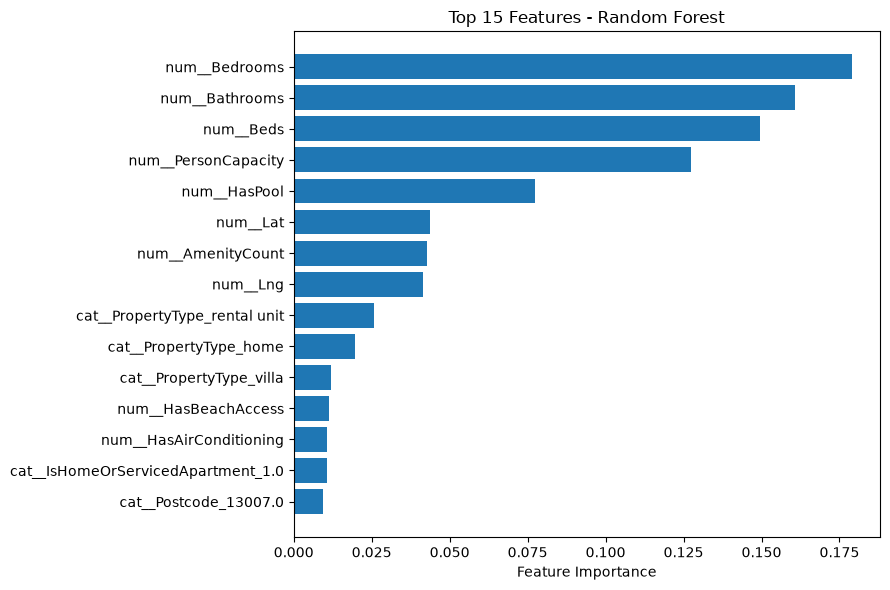

In [132]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Features - Random Forest")
plt.tight_layout()
plt.show()

## 12. Error Analysis

In [133]:
from sklearn.model_selection import cross_val_score

In [134]:
cv_scores = cross_val_score(
    rf_enriched,
    X_enriched,
    y_enriched,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("R² por fold:", cv_scores)
print("R² medio:", cv_scores.mean())
print("Desviación:", cv_scores.std())

R² por fold: [0.61243606 0.67745792 0.54152009 0.64722165 0.63983302]
R² medio: 0.6236937508761562
Desviación: 0.046008412308719375


In [135]:
error_analysis = X_test_enriched.copy()

error_analysis["ActualPrice"] = y_test_enriched
error_analysis["PredictedPrice"] = pred_enriched
error_analysis["Error"] = (
    error_analysis["ActualPrice"] -
    error_analysis["PredictedPrice"]
)

error_analysis["AbsoluteError"] = error_analysis["Error"].abs()

In [136]:
error_analysis.sort_values(
    "AbsoluteError",
    ascending=False
)[
    [
        "ActualPrice",
        "PredictedPrice",
        "AbsoluteError",
        "Bedrooms",
        "Bathrooms",
        "PersonCapacity",
        "PropertyType",
        "HasPool",
        "AmenityCount"
    ]
].head(15)

,ActualPrice,PredictedPrice,AbsoluteError,Bedrooms,Bathrooms,PersonCapacity,PropertyType,HasPool,AmenityCount
3584,1060.0,119.132409,940.867591,1.0,1.0,2.0,rental unit,0.0,44.0
4464,923.0,253.808237,669.191763,2.0,2.0,4.0,rental unit,0.0,27.0
1112,945.0,490.834976,454.165024,5.0,4.0,10.0,rental unit,0.0,51.0
870,935.0,481.673228,453.326772,3.0,2.0,6.0,villa,1.0,53.0
2814,832.0,403.973405,428.026595,4.0,2.0,8.0,home,0.0,53.0
472,912.0,484.171827,427.828173,5.0,3.5,10.0,home,1.0,32.0
3903,860.0,486.861937,373.138063,5.0,3.0,8.0,home,1.0,23.0
3739,830.0,466.714995,363.285005,5.0,3.0,10.0,villa,1.0,49.0
278,826.0,489.634827,336.365173,4.0,2.0,8.0,villa,1.0,39.0
430,685.0,378.501970,306.498030,3.0,1.0,5.0,villa,1.0,50.0


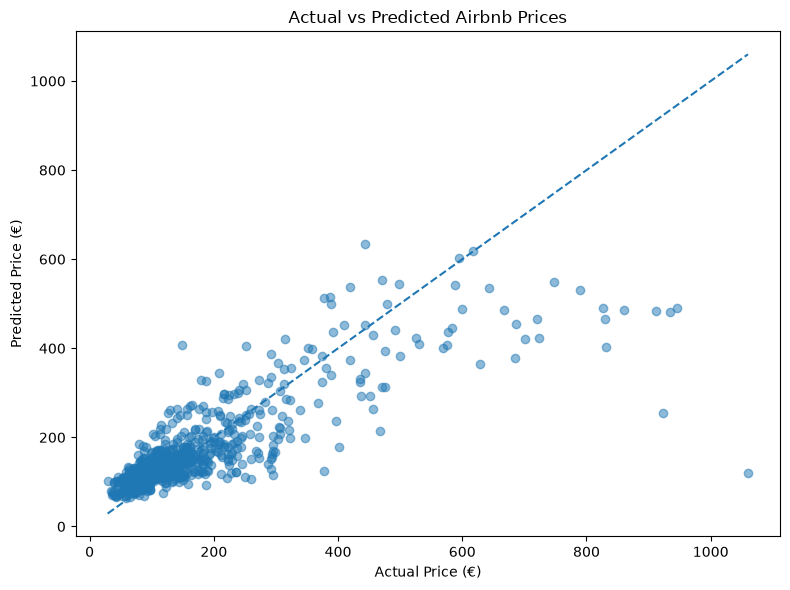

In [137]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_enriched,
    pred_enriched,
    alpha=0.5
)

plt.plot(
    [y_test_enriched.min(), y_test_enriched.max()],
    [y_test_enriched.min(), y_test_enriched.max()],
    linestyle="--"
)

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.tight_layout()
plt.show()

In [138]:
error_analysis["PriceGroup"] = pd.cut(
    error_analysis["ActualPrice"],
    bins=[0, 100, 200, 300, 500, float("inf")],
    labels=["0-100", "100-200", "200-300", "300-500", "500+"]
)

error_by_price = error_analysis.groupby(
    "PriceGroup",
    observed=True
).agg(
    Count=("ActualPrice", "size"),
    MeanActualPrice=("ActualPrice", "mean"),
    MAE=("AbsoluteError", "mean"),
    MeanError=("Error", "mean")
)

error_by_price

,Count,MeanActualPrice,MAE,MeanError
PriceGroup,,,,
0-100,261,76.931034,32.115450,-31.194671
100-200,347,135.991354,27.414084,-11.393759
200-300,93,242.215054,62.283172,32.384806
300-500,54,387.518519,90.577198,42.492806
500+,29,719.931034,270.185050,269.606102


### Log-Target Experiment

Error analysis showed that prediction errors increased substantially for high-priced listings. The model tended to overestimate lower-priced properties and underestimate premium listings, suggesting that the strongly right-skewed target distribution was affecting performance.

To investigate this issue, a second Random Forest model was trained using `log1p(BasicNightPrice)` as the target. The logarithmic transformation compresses extreme values and reduces their influence during training.

Predictions were transformed back to euros using `expm1()` so that performance could be evaluated on the original price scale.

In [139]:
y_train_log = np.log1p(y_train_enriched)

In [140]:
rf_log = Pipeline(
    steps=[
        ("preprocessor", preprocessor_enriched),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [141]:
rf_log.fit(X_train_enriched, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Bedrooms','Bathrooms','Beds',...,'Postcode','IsHomeOrServicedApartment', 'PropertyType']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [142]:
pred_log = rf_log.predict(X_test_enriched)

pred_price_log = np.expm1(pred_log)

In [143]:
print("MAE:", mean_absolute_error(y_test_enriched, pred_price_log))
print("RMSE:", np.sqrt(mean_squared_error(y_test_enriched, pred_price_log)))
print("R²:", r2_score(y_test_enriched, pred_price_log))

MAE: 45.10870545801748
RMSE: 87.14389890328367
R²: 0.6194268574800241


In [144]:
error_log = X_test_enriched.copy()

error_log["ActualPrice"] = y_test_enriched
error_log["PredictedPrice"] = pred_price_log
error_log["Error"] = error_log["ActualPrice"] - error_log["PredictedPrice"]
error_log["AbsoluteError"] = error_log["Error"].abs()

error_log["PriceGroup"] = pd.cut(
    error_log["ActualPrice"],
    bins=[0, 100, 200, 300, 500, float("inf")],
    labels=["0-100", "100-200", "200-300", "300-500", "500+"]
)

error_log.groupby(
    "PriceGroup",
    observed=True
).agg(
    Count=("ActualPrice", "size"),
    MAE=("AbsoluteError", "mean"),
    MeanError=("Error", "mean")
)

,Count,MAE,MeanError
PriceGroup,,,
0-100,261,23.548654,-20.789328
100-200,347,24.278490,-1.074721
200-300,93,68.883259,53.865603
300-500,54,98.359415,78.003783
500+,29,312.994444,312.994444


The log-target model reduced the overall MAE and improved predictions for listings below €200 per night. However, RMSE and R² deteriorated, and the model showed stronger underestimation for premium properties.

For this reason, the standard-price Random Forest was retained as the main model, while the log-target experiment illustrates the trade-off between improving typical predictions and preserving performance on high-priced listings.

## 13. Conclusions

This project investigated the feasibility of estimating Airbnb nightly prices in Marseille using property characteristics, geographic information, and amenities data.

A linear regression model was initially used as a baseline, but its performance suggested that the relationship between listing characteristics and price was not sufficiently captured by a simple linear model. Random Forest provided substantially better performance, although the initial model showed signs of overfitting. Cross-validation and hyperparameter tuning were therefore used to improve generalization.

Feature engineering produced additional improvements. In particular, integrating a separate amenities dataset and creating property-level features such as pool availability, parking, outdoor space, sea view, beach access, air conditioning, and total amenity count improved predictive performance on listings for which amenity information was available.

The final enriched Random Forest achieved:

- **Test R²:** 0.657
- **Test MAE:** €46.45
- **Test RMSE:** €82.68
- **5-fold CV R²:** 0.624 ± 0.046

Feature importance showed that property size and capacity were the strongest predictors of nightly price. Bedrooms, bathrooms, beds, and guest capacity dominated the model, while pool availability was the most influential engineered amenity feature.

### Limitations

Error analysis revealed an important limitation: model performance was not uniform across price segments. Predictions were substantially more accurate for lower- and mid-priced listings, while expensive properties were systematically underestimated.

For listings priced above €500, the model produced much larger errors, suggesting that the available variables do not fully capture characteristics that distinguish premium properties, such as property quality, interior design, exact micro-location, exceptional views, or other luxury attributes.

Amenities data also covered only 3,918 of the 5,758 listings in the modeling sample. Therefore, results from the enriched model should not be interpreted as representative of listings without amenity information.

A logarithmic transformation of the target improved MAE for lower- and mid-priced listings but further increased underestimation of premium properties. The standard-price Random Forest was therefore retained as the main model.

### Final Takeaway

The project demonstrates that Airbnb pricing contains meaningful patterns that can be captured using property, geographic, and amenity information, but also shows the limits of price prediction when important qualitative characteristics are unavailable.

Rather than treating the model as a production-ready pricing tool, its results are best interpreted as an analysis of the predictive information contained in the available data and an example of an end-to-end machine learning workflow.